# 01 — Data Exploration & Week 1 Summary

Explores the synthetic vitals dataset (`src/data/synth_data.py`) and the engineered/split output (`src/data/feature_engineering.py`). Harespod is not yet downloaded (manual Figshare step) -- see `src/data/harespod_loader.py` for the ready adapter and CLAUDE.md Section 5 for the plan once it lands.

Run `python -m src.data.synth_data` then `python -m src.data.feature_engineering` from the project root before running this notebook, so `data/synthetic/` and `data/processed/` are populated.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # so `import src...` works from notebooks/

import pandas as pd
import matplotlib.pyplot as plt

from src.config import PROCESSED_DIR, SYNTHETIC_DIR, SEVERITY_TIERS

raw = pd.read_csv(SYNTHETIC_DIR / "synthetic_vitals.csv")  # full synthetic dataset (all subjects, pre-split)
train = pd.read_csv(PROCESSED_DIR / "train.csv")  # 70% of subjects (stratified-temporal split, see feature_engineering.temporal_split)
val = pd.read_csv(PROCESSED_DIR / "val.csv")  # 15% of subjects
test = pd.read_csv(PROCESSED_DIR / "test.csv")  # 15% of subjects
raw.shape, train.shape, val.shape, test.shape

((2160000, 7), (1545756, 15), (307800, 15), (351000, 15))

## Class balance across the temporal, tier-stratified split

Every tier must appear in every split (this is what `tests/test_pipeline.py::test_temporal_split_no_subject_overlap` guards against regressing) -- an earlier version of the split used a plain chronological cut across all subjects and, by bad luck of subject ordering, produced a **test set with zero HACE-risk examples**. Stratifying the temporal cut per severity tier (still no row-level shuffling -- see `feature_engineering.temporal_split`'s docstring) fixed this.

In [2]:
for name, df in [("train", train), ("val", val), ("test", test)]:  # check every split has all 5 severity tiers represented (the bug this guards against: an earlier plain chronological split produced a test set with zero HACE-risk rows)
    print(name, df["subject_id"].nunique(), "subjects")  # how many distinct subjects landed in this split
    print(df["severity_label"].value_counts())  # row count per tier within this split
    print()

train 293 subjects
severity_label
Normal        897674
Mild AMS      262512
Severe AMS    228912
HAPE risk      86458
HACE risk      70200
Name: count, dtype: int64

val 57 subjects
severity_label
Normal        189000
Mild AMS       54000
Severe AMS     37800
HAPE risk      16200
HACE risk      10800
Name: count, dtype: int64

test 65 subjects
severity_label
Normal        199800
Mild AMS       59400
Severe AMS     48600
HACE risk      21600
HAPE risk      21600
Name: count, dtype: int64



## Example trajectories per tier

Sanity check that onset is gradual (sigmoid ramp), not a step function -- see `synth_data.py`'s `_smooth_ramp`.

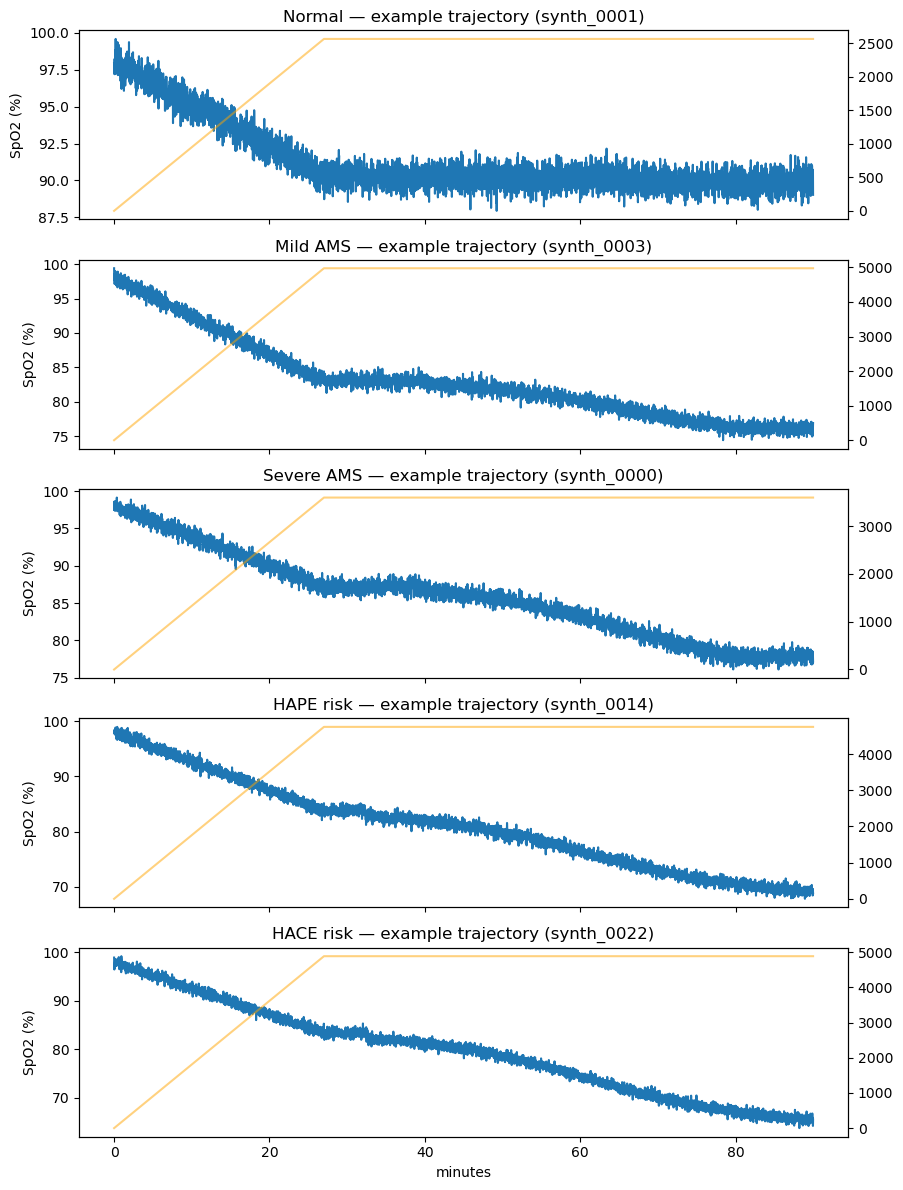

In [3]:
fig, axes = plt.subplots(len(SEVERITY_TIERS), 1, figsize=(9, 12), sharex=True)  # one stacked subplot per severity tier, sharing the x-axis so trajectories line up in time
for ax, tier in zip(axes, SEVERITY_TIERS):
    subj = raw[raw["severity_label"] == tier]["subject_id"].iloc[0]  # grab one example subject_id for this tier
    traj = raw[raw["subject_id"] == subj].sort_values("timestamp")  # that subject's full trajectory, in time order
    ax.plot(traj["timestamp"] / 60, traj["spo2"], label="SpO2")  # convert seconds to minutes for a readable x-axis
    ax2 = ax.twinx()  # second y-axis sharing the same x-axis, so altitude and SpO2 can be compared on their own natural scales
    ax2.plot(traj["timestamp"] / 60, traj["altitude"], color="orange", alpha=0.5, label="altitude")  # overlay altitude (meters) on the twin axis
    ax.set_title(f"{tier} — example trajectory ({subj})")
    ax.set_ylabel("SpO2 (%)")
axes[-1].set_xlabel("minutes")
fig.tight_layout()

## Model comparison recap (Days 4-7)

See `src/models/artifacts/model_comparison.json` (written by `python -m src.models.predict_severity`) for the machine-readable record. As of the last run:

| Model | Precision (macro) | Recall (macro) | F1 (macro) | Mean Abs Tier Error | Under-triage rate |
|---|---|---|---|---|---|
| Rule-Based Baseline | 0.349 | 0.287 | 0.285 | 0.819 | 0.309 |
| XGBoost Ordinal | 0.387 | 0.405 | 0.374 | **0.594** | 0.221 |
| LSTM | 0.405 | 0.370 | 0.374 | 0.785 | 0.235 |

**XGBoost Ordinal selected** (lowest mean-abs-tier-error, clearly beats the rule-based sanity floor). Feature importances show `spo2_delta` and `time_at_altitude_min` dominate -- consistent with `docs/lls_mapping.md`'s reasoning that deviation-from-altitude-expected SpO2 (not raw SpO2) and cumulative exposure time are the clinically meaningful signals, not any single instantaneous reading.